In [8]:
from simulator import Config, Simulator

config = Config()
config.NODE_POWER_W = 0.02  # Node power consumption in kW
simulator = Simulator(config)

# CSV including time series data for production (G(h) in kWh, and Temperature in °C)
production_data = "raw-data/Quito.csv"

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from visualization import (
    get_config_trace,
    plot_soc,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc,
    plot_full_soc_analysis,
)


## Run Complete Simulation

This single function call executes the entire pipeline:
1. Load irradiance data
2. Compute PV power for all panel sizes
3. Compute hourly power balance with PMU efficiency
4. Simulate battery State of Charge for all configurations
5. Evaluate viability and compute scores

In [ ]:
# Run the full simulation
results = simulator.run_full_simulation(production_data)

# Extract results
df_pv = results['df_pv']
df_pv_pmu = results['df_pv_pmu']
df_soc = results['df_soc']
summary = results['summary']

Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...


## Design space

In [ ]:
df_design = simulator.build_design_space()
df_design

## Explore Results

In [13]:
print("Top 10 configurations by score:")
summary.head(10)

Top 10 configurations by score:


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
0,0.001,0.35,0.90,8760,0,1049,0.863284,0.106919,29.855022,40.943915,8760,0,0.525,0.030954,0.0,0.119749,-11.088894,0.880995
1,0.001,0.40,0.90,8760,0,1049,0.880373,0.093554,29.855022,40.943915,8760,0,0.600,0.030954,0.0,0.119749,-11.088894,0.875610
2,0.001,0.42,0.90,8760,0,1049,0.886070,0.089099,29.855022,40.943915,8760,0,0.630,0.030954,0.0,0.119749,-11.088894,0.873456
3,0.001,0.50,0.90,8760,0,1049,0.904298,0.074844,29.855022,40.943915,8760,0,0.500,0.030954,0.0,0.119749,-11.088894,0.864840
4,0.001,0.35,0.95,8760,0,1534,0.892939,0.084794,28.184699,46.611242,8760,0,0.525,0.034774,0.0,0.175114,-18.426543,0.841612
5,0.001,0.40,0.95,8760,0,1534,0.906321,0.074194,28.184699,46.611242,8760,0,0.600,0.034774,0.0,0.175114,-18.426543,0.836227
6,0.001,0.42,0.95,8760,0,1534,0.910782,0.070661,28.184699,46.611242,8760,0,0.630,0.034774,0.0,0.175114,-18.426543,0.834073
7,0.001,1.20,0.87,8760,0,603,0.941896,0.052225,30.953961,37.718412,8760,0,1.200,0.028768,0.0,0.068836,-6.764451,0.825666
8,0.001,0.50,0.95,8760,0,1534,0.925057,0.059355,28.184699,46.611242,8760,0,0.500,0.034774,0.0,0.175114,-18.426543,0.825457
9,0.001,0.35,0.98,8760,0,1743,0.901922,0.079888,27.268561,50.187134,8760,0,0.525,0.037173,0.0,0.198973,-22.918572,0.824641


## Best combinations

In [14]:
best_configs = summary[summary["score"] == summary["score"].max()]

for config_idx, config_row in best_configs.iterrows():
    print()
    print(config_row[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])


panel_area_m2    0.001000
C_batt_Ah        0.350000
eta_PMU          0.900000
score            0.880995
Name: 0, dtype: float64


for _, cfg in best_configs.iterrows():
    config_soc = df_soc[
        (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
        (df_soc['C_batt_Ah'] == cfg['C_batt_Ah']) &
        (df_soc['eta_PMU'] == cfg['eta_PMU'])
    ].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(config_soc['hour_index'], config_soc['SoC'])
    plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
    plt.xlabel('Hour index')
    plt.ylabel('State of Charge (SoC)')
    plt.title(
        f"SoC over time – A={cfg['panel_area_m2']} m², "
        f"C={cfg['C_batt_Ah']} Ah, ηPMU={cfg['eta_PMU']}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Plot best configurations

Visualize all configurations in 3D space (panel area × battery capacity × PMU efficiency)

In [22]:
LOG_COLOR = False

data = summary.copy()

if LOG_COLOR:
    eps = 1e-9
    data["score_color"] = np.log10(data["score"] + eps)
    color_label = "log10(score)"
else:
    data["score_color"] = data["score"]
    color_label = "score"

fig = px.scatter_3d(
    data,
    x="panel_area_m2",
    y="C_batt_Ah",
    z="eta_PMU",
    color="score_color",
    labels={
        "panel_area_m2": "Panel area (m²)",
        "C_batt_Ah": "Battery (Ah)",
        "eta_PMU": "PMU efficiency",
        "score_color": color_label
    },
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=800,
    title=f"All configurations ({'log color scale' if LOG_COLOR else 'linear color scale'})"
)

fig.show()

## Score Distribution Histogram

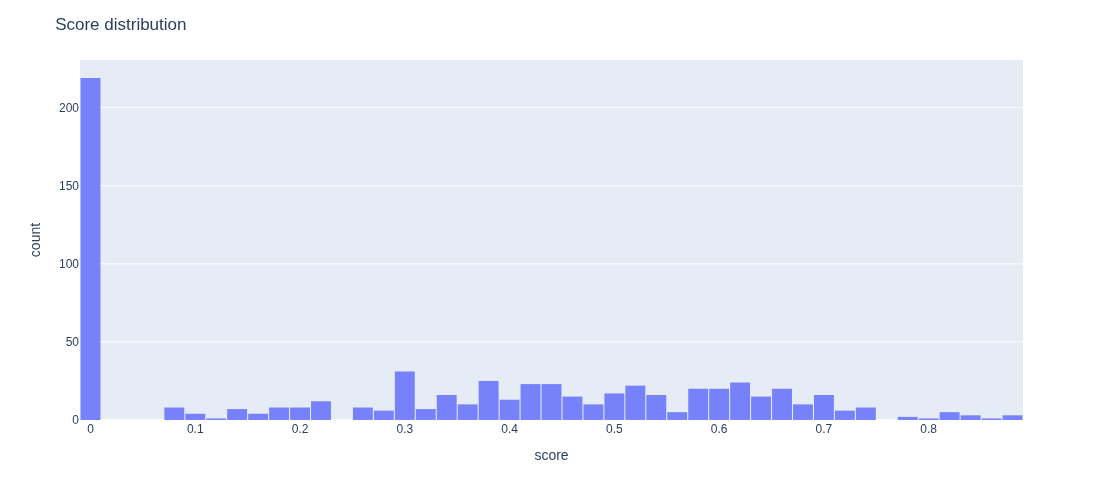

In [23]:
fig = px.histogram(
    summary,
    x="score",
    nbins=50,
    labels={"score": "score"},
    opacity=0.85,
)

fig.update_layout(
    width=900,
    height=500,
    title="Score distribution",
    bargap=0.05
)

fig.show()

## Score at Maximum PMU Efficiency (not best configs)

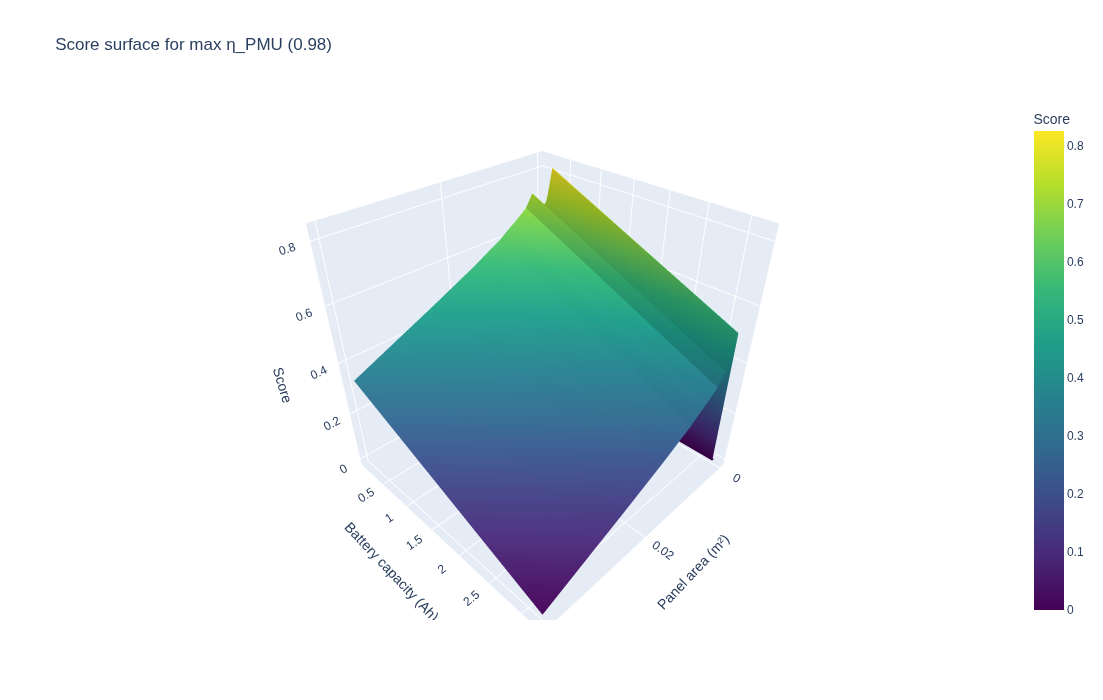

In [24]:
eta_max = summary["eta_PMU"].max()
df_plane = summary[summary["eta_PMU"] == eta_max].copy()

df_pivot = (
    df_plane
    .pivot_table(
        index="C_batt_Ah",
        columns="panel_area_m2",
        values="score",
        aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

X = df_pivot.columns.values
Y = df_pivot.index.values
X_grid, Y_grid = np.meshgrid(X, Y)
Z = df_pivot.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X_grid,
            y=Y_grid,
            z=Z,
            colorscale="Viridis",
            colorbar={"title": "Score"}
        )
    ]
)

fig.update_layout(
    title=f"Score surface for max η_PMU ({eta_max})",
    scene=dict(
        xaxis_title="Panel area (m²)",
        yaxis_title="Battery capacity (Ah)",
        zaxis_title="Score"
    ),
    width=900,
    height=700
)

fig.show()

## Summary statistics

In [25]:
print("\n=== Simulation Summary ===")
print(f"Total configurations evaluated: {len(summary)}")
print(f"Best score achieved: {summary['score'].max():.4f}")
print(f"Configurations with best score: {len(summary[summary['score'] == summary['score'].max()])}")
print(f"Configurations with failures: {len(summary[summary['failure_hours'] > 0])}")
print("Configuration with I_req_max > I_batt_max):",
      len(summary[summary["I_req_max_A"] > summary["I_batt_max_A"]]))



=== Simulation Summary ===
Total configurations evaluated: 672
Best score achieved: 0.8810
Configurations with best score: 1
Configurations with failures: 215
Configuration with I_req_max > I_batt_max): 123


## Invalidad configs due to < SoC_min

In [26]:
invalid_soc = summary[summary["failure_hours"] > 0][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "failure_hours",
    "autonomy_hours",
    "I_batt_max_A",
    "I_req_max_A"
]].sort_values("failure_hours", ascending=False)

invalid_soc


,panel_area_m2,C_batt_Ah,eta_PMU,failure_hours,autonomy_hours,I_batt_max_A,I_req_max_A
657,0.0001,0.105,0.87,8746,14,0.1575,0.006213
640,0.0001,0.105,0.90,8745,15,0.1575,0.006006
671,0.0001,0.105,0.95,8744,16,0.1575,0.005690
659,0.0001,0.105,0.98,8743,17,0.1575,0.005516
658,0.0001,0.120,0.87,8743,17,0.2400,0.006213
...,...,...,...,...,...,...,...
647,0.0010,0.400,0.87,28,8626,0.6000,0.028768
652,0.0010,0.420,0.87,25,8629,0.6300,0.028768
645,0.0010,0.120,0.98,25,2471,0.2400,0.037173
653,0.0010,0.500,0.87,14,8692,0.5000,0.028768


## Invalid configs due I_req > I_batt_max

In [27]:
invalid_peak = summary[
    summary["I_req_max_A"] > summary["I_batt_max_A"]
][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "I_req_max_A",
    "I_batt_max_A",
    "failure_hours",
    "autonomy_hours"
]].sort_values("I_req_max_A", ascending=False)

invalid_peak


,panel_area_m2,C_batt_Ah,eta_PMU,I_req_max_A,I_batt_max_A,failure_hours,autonomy_hours
452,0.04000,2.500,0.98,1.693497,1.5000,0,8760
386,0.04000,0.500,0.98,1.693497,0.5000,0,8760
346,0.04000,0.105,0.98,1.693497,0.1575,0,8760
348,0.04000,0.120,0.98,1.693497,0.2400,0,8760
361,0.04000,0.350,0.98,1.693497,0.5250,0,8760
...,...,...,...,...,...,...,...
67,0.00625,0.105,0.95,0.244299,0.1575,0,8760
69,0.00625,0.120,0.95,0.244299,0.2400,0,8760
63,0.00625,0.105,0.90,0.219004,0.1575,0,8760
589,0.00625,0.105,0.87,0.204490,0.1575,259,983


In [28]:
summary["autonomy_hours"].describe()


count     672.000000
mean     6170.696429
std      3849.887692
min        14.000000
25%       726.250000
50%      8760.000000
75%      8760.000000
max      8760.000000
Name: autonomy_hours, dtype: float64

In [29]:
summary.sort_values("autonomy_hours").head(5)


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
657,0.0001,0.105,0.87,8760,8746,1,0.200635,0.018709,47.096277,-0.0,14,8746,0.1575,0.006213,0.998402,0.000114,47.096277,0.0
640,0.0001,0.105,0.90,8760,8745,1,0.200657,0.018997,45.282049,-0.0,15,8745,0.1575,0.006006,0.998288,0.000114,45.282049,0.0
671,0.0001,0.105,0.95,8760,8744,1,0.200696,0.019476,42.512964,-0.0,16,8744,0.1575,0.005690,0.998174,0.000114,42.512964,0.0
663,0.0001,0.120,0.90,8760,8743,1,0.200757,0.020218,45.282049,-0.0,17,8743,0.2400,0.006006,0.998059,0.000114,45.282049,0.0
658,0.0001,0.120,0.87,8760,8743,1,0.200729,0.019892,47.096277,-0.0,17,8743,0.2400,0.006213,0.998059,0.000114,47.096277,0.0


In [30]:
summary.sort_values("autonomy_hours").tail(5)

,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
20,0.0025,0.105,0.95,8760,0,3040,0.741871,0.257926,26.944186,144.729182,8760,0,0.1575,0.094639,0.0,0.347032,-117.784996,0.733178
19,0.0010,2.000,0.87,8760,0,603,0.965137,0.031335,30.953961,37.718412,8760,0,2.0000,0.028768,0.0,0.068836,-6.764451,0.739505
18,0.0025,0.120,0.90,8760,0,2942,0.755880,0.239330,28.490601,128.905081,8760,0,0.2400,0.084683,0.0,0.335845,-100.414480,0.739520
17,0.0010,1.600,0.90,8760,0,1049,0.970093,0.023389,29.855022,40.943915,8760,0,4.8000,0.030954,0.0,0.119749,-11.088894,0.746369
16,0.0025,0.120,0.87,8760,0,2853,0.743480,0.248309,29.509063,119.852321,8760,0,0.2400,0.078974,0.0,0.325685,-90.343258,0.746747


In [31]:
# 1) Maximum score configuration
cfg_best = summary.sort_values("score", ascending=False).iloc[0]

# 2) Minimum non-zero score configuration
summary_nonzero = summary[summary["score"] > 0]
cfg_bad = summary_nonzero.sort_values("score", ascending=True).iloc[0]

# 3) Score closest to 0.5 (mid-score representative)
target = 0.5
idx_mid = (summary["score"] - target).abs().idxmin()
cfg_mid = summary.loc[idx_mid]

# 4) Failure case (for comparison)
cfg_fail = summary[summary["score"] == 0].sort_values("score").iloc[0]


print("\n=== BEST SCORE CONFIGURATION ===")
print(cfg_best[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== BAD NON-ZERO SCORE CONFIGURATION ===")
print(cfg_bad[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== MID-SCORE (~0.5) CONFIGURATION ===")
print(cfg_mid[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== FAILURE CASE CONFIGURATION ===")
print(cfg_fail[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])



=== BEST SCORE CONFIGURATION ===
panel_area_m2    0.001000
C_batt_Ah        0.350000
eta_PMU          0.900000
score            0.880995
Name: 0, dtype: float64

=== BAD NON-ZERO SCORE CONFIGURATION ===
panel_area_m2    0.040000
C_batt_Ah        3.200000
eta_PMU          0.950000
score            0.001137
Name: 455, dtype: float64

=== MID-SCORE (~0.5) CONFIGURATION ===
panel_area_m2    0.010000
C_batt_Ah        1.200000
eta_PMU          0.870000
score            0.500214
Name: 202, dtype: float64

=== FAILURE CASE CONFIGURATION ===
panel_area_m2    0.00025
C_batt_Ah        2.50000
eta_PMU          0.95000
score            0.00000
Name: 456, dtype: float64


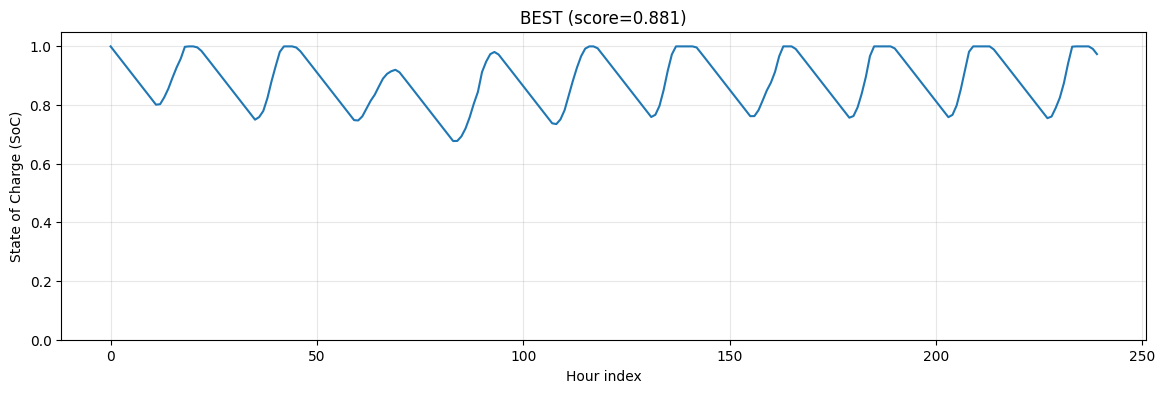

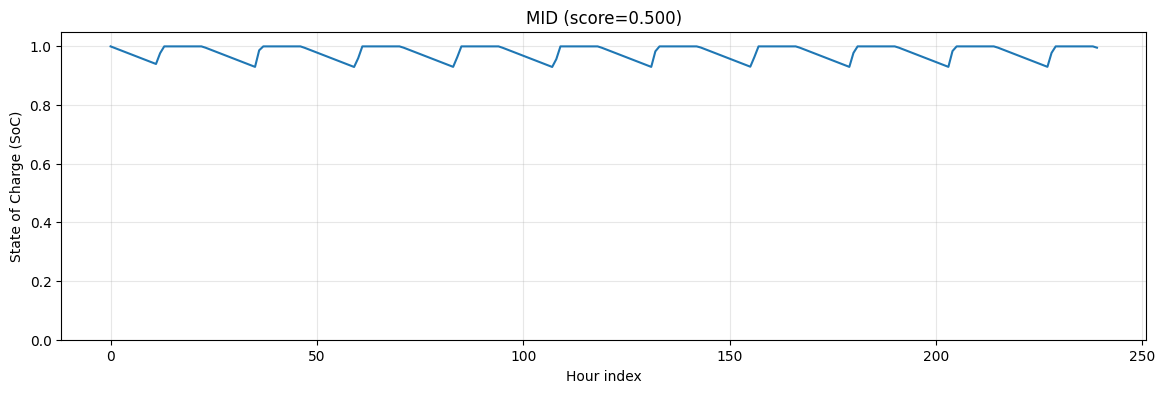

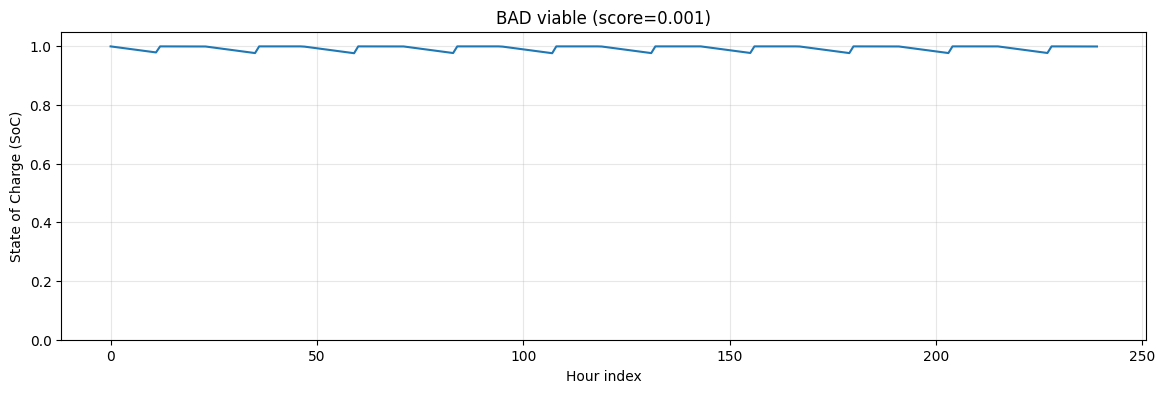

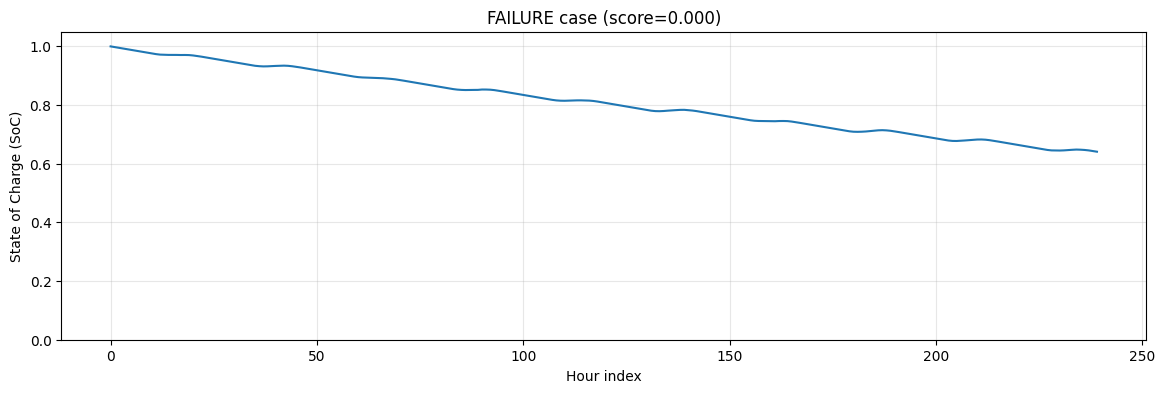

In [32]:
# BEST SCORE
plot_soc(
    df_soc,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    title=f"BEST (score={cfg_best['score']:.3f})"
)

# MID SCORE (~0.5)
plot_soc(
    df_soc,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    title=f"MID (score={cfg_mid['score']:.3f})"
)

# BAD NON-ZERO SCORE
plot_soc(
    df_soc,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    title=f"BAD viable (score={cfg_bad['score']:.3f})"
)

# FAILURE CASE
plot_soc(
    df_soc,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    title=f"FAILURE case (score={cfg_fail['score']:.3f})"
)

In [33]:
from visualization import (
    get_config_trace,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc
)


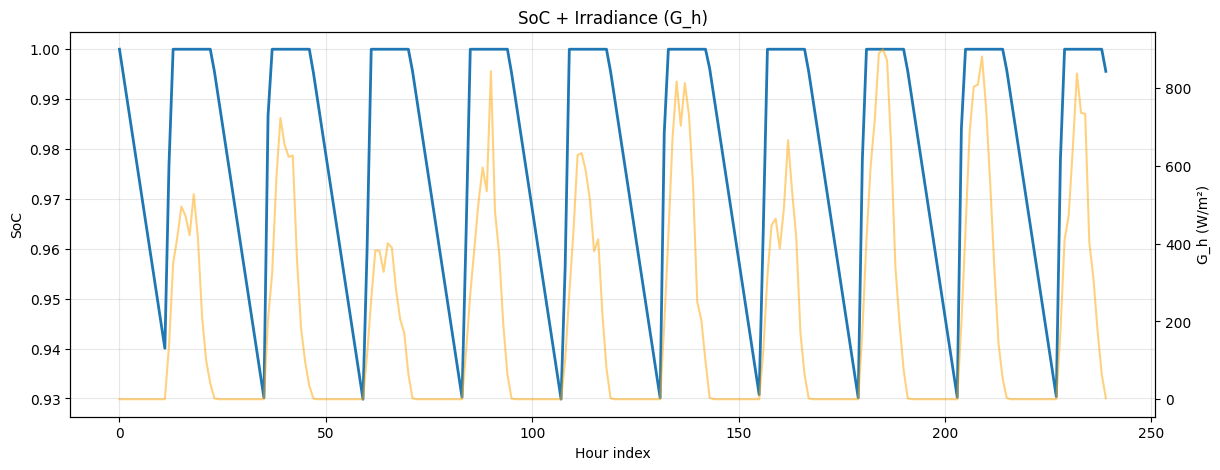

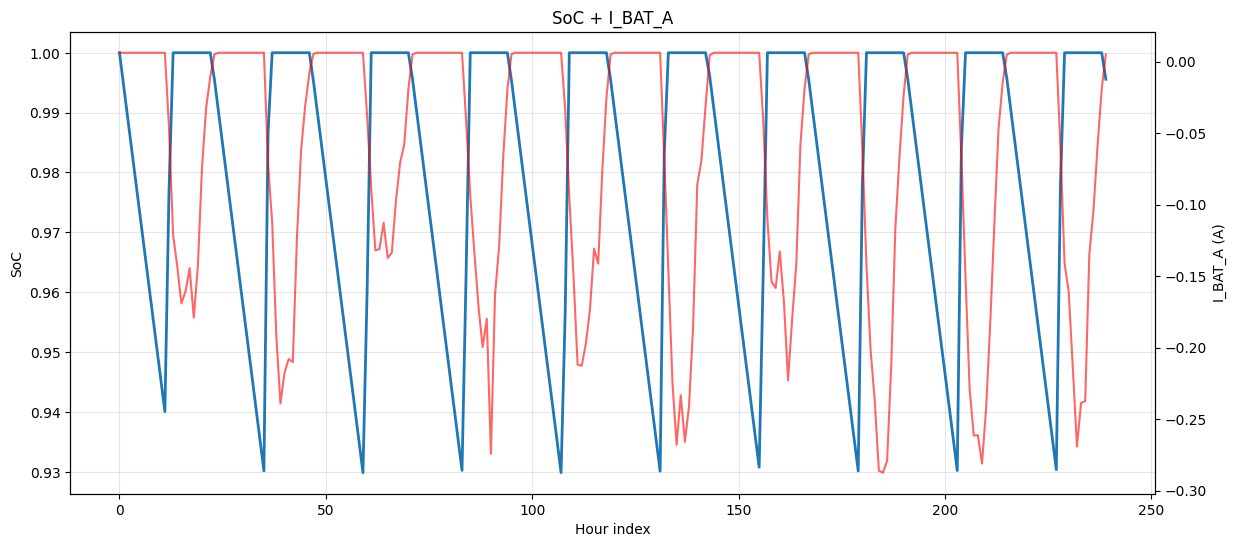

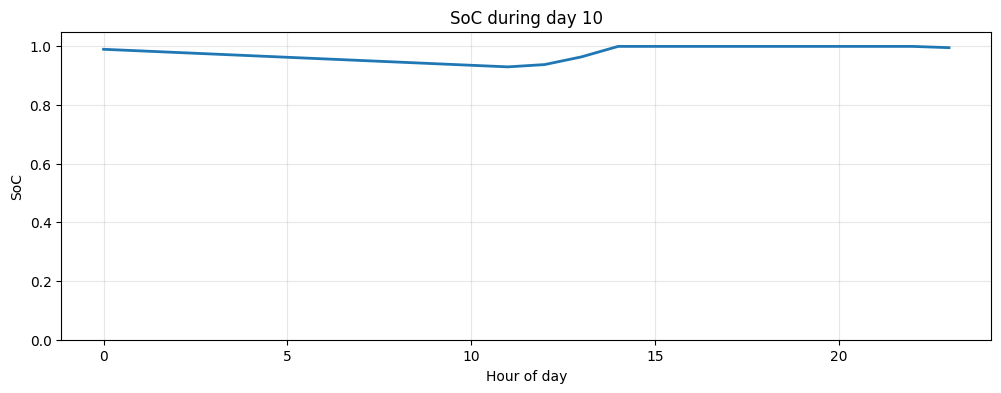

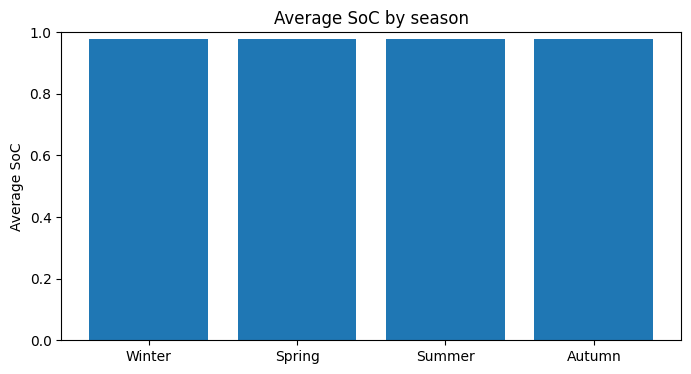

In [34]:
# Choose a configuration, e.g. cfg_mid (score ~0.5)
panel  = cfg_mid["panel_area_m2"]
cap    = cfg_mid["C_batt_Ah"]
eta    = cfg_mid["eta_PMU"]

cfg = get_config_trace(df_soc, panel, cap, eta)

plot_soc_gh(cfg, df_pv, hours=240, title="SoC + Irradiance (G_h)")
plot_soc_ibatt(cfg, hours=240, title="SoC + I_BAT_A")
plot_daily(cfg, day_index=10)
plot_seasonal_soc(cfg)


In [35]:
# Sort all configurations by score
summary_sorted = summary.sort_values("score", ascending=False)

# 1) Best score
cfg_best = summary_sorted.iloc[0]
title_best = f"BEST - Panel: {cfg_best['panel_area_m2']} m², Batería: {cfg_best['C_batt_Ah']} Ah, PMU: {cfg_best['eta_PMU']}, Score: {cfg_best['score']:.3f}"

# 2) BAD non-zero score
cfg_bad = summary_sorted[summary_sorted["score"] > 0].sort_values("score").iloc[0]
title_bad = f"BAD - Panel: {cfg_bad['panel_area_m2']} m², Batería: {cfg_bad['C_batt_Ah']} Ah, PMU: {cfg_bad['eta_PMU']}, Score: {cfg_bad['score']:.3f}"

# 3) MID score (between BAD and BEST)
configs_between = summary_sorted[
    (summary_sorted["score"] > cfg_bad["score"]) &
    (summary_sorted["score"] < cfg_best["score"])
].sort_values("score")
cfg_mid = configs_between.iloc[len(configs_between) // 2]
title_mid = f"MID - Panel: {cfg_mid['panel_area_m2']} m², Batería: {cfg_mid['C_batt_Ah']} Ah, PMU: {cfg_mid['eta_PMU']}, Score: {cfg_mid['score']:.3f}"

# 4) Failure case (for comparison)
cfg_fail = summary_sorted[summary_sorted["score"] == 0].sort_values("score").iloc[0]
title_fail = f"FAIL - Panel: {cfg_fail['panel_area_m2']} m², Batería: {cfg_fail['C_batt_Ah']} Ah, PMU: {cfg_fail['eta_PMU']}, Score: {cfg_fail['score']:.3f}"

print("\nBEST:", cfg_best[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nMID:", cfg_mid[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nBAD:", cfg_bad[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nFAIL:", cfg_fail[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])



BEST: panel_area_m2    0.001000
C_batt_Ah        0.350000
eta_PMU          0.900000
score            0.880995
Name: 0, dtype: float64

MID: panel_area_m2    0.025000
C_batt_Ah        0.105000
eta_PMU          0.950000
score            0.464656
Name: 227, dtype: float64

BAD: panel_area_m2    0.040000
C_batt_Ah        3.200000
eta_PMU          0.950000
score            0.001137
Name: 455, dtype: float64

FAIL: panel_area_m2    0.00025
C_batt_Ah        2.50000
eta_PMU          0.95000
score            0.00000
Name: 456, dtype: float64


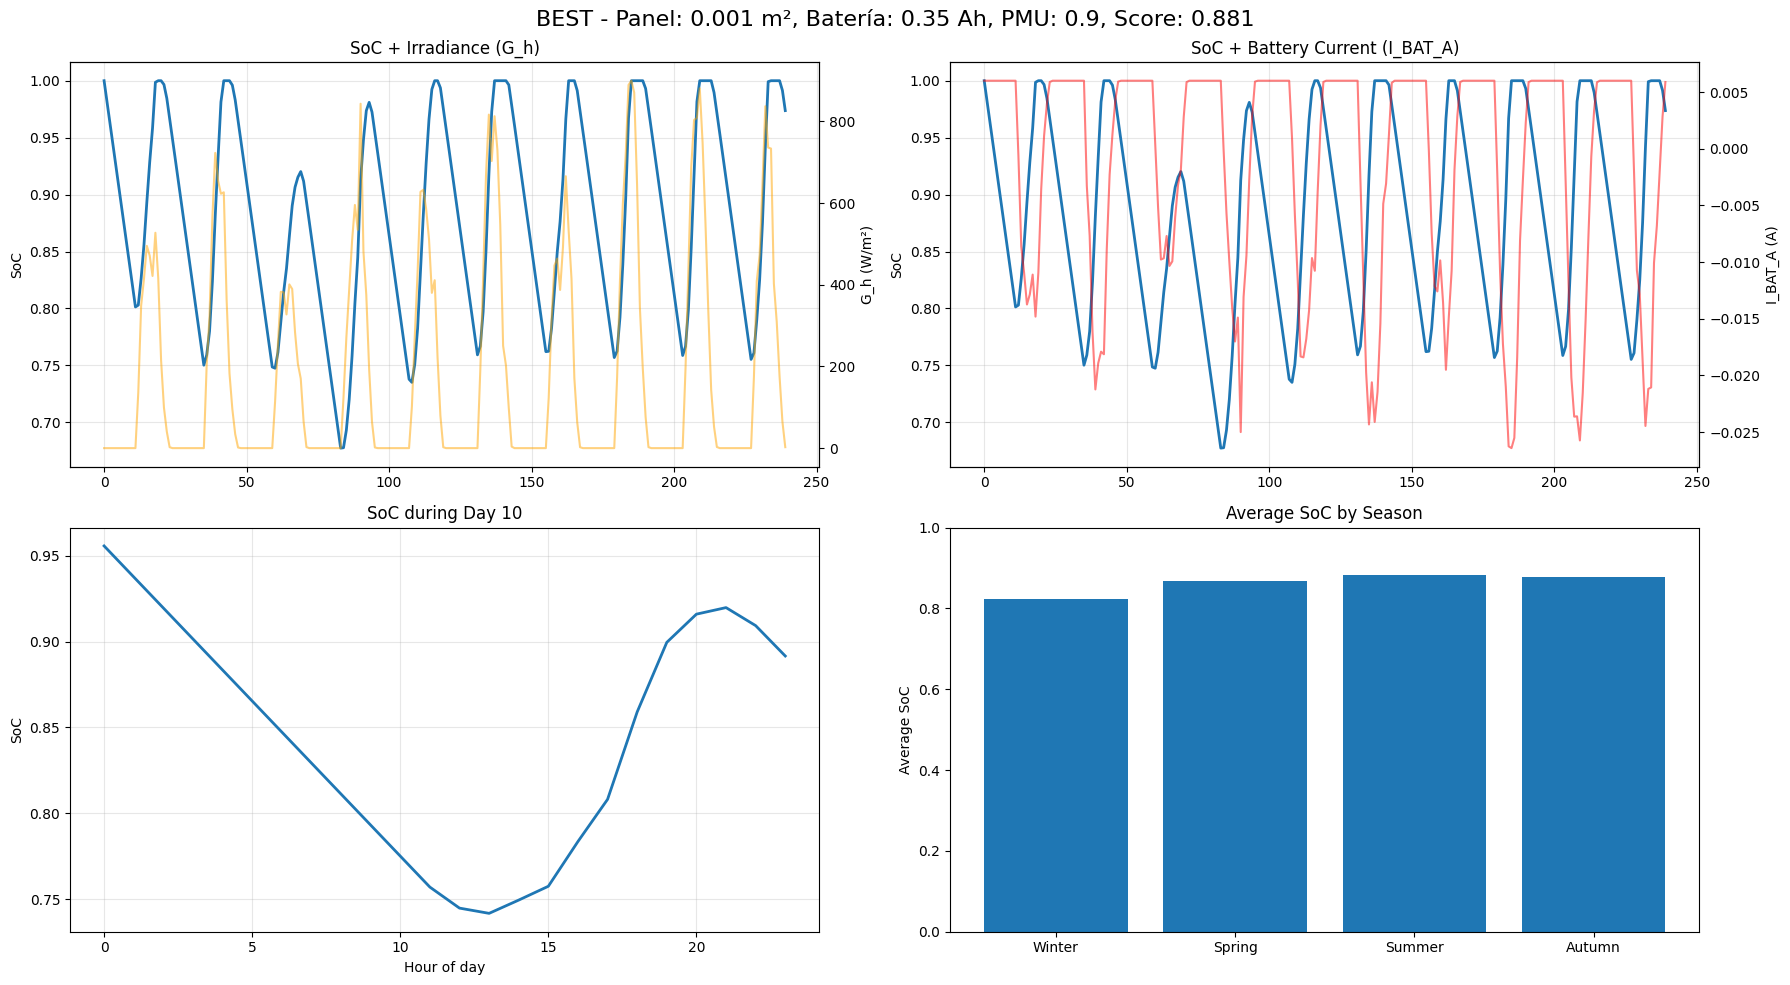

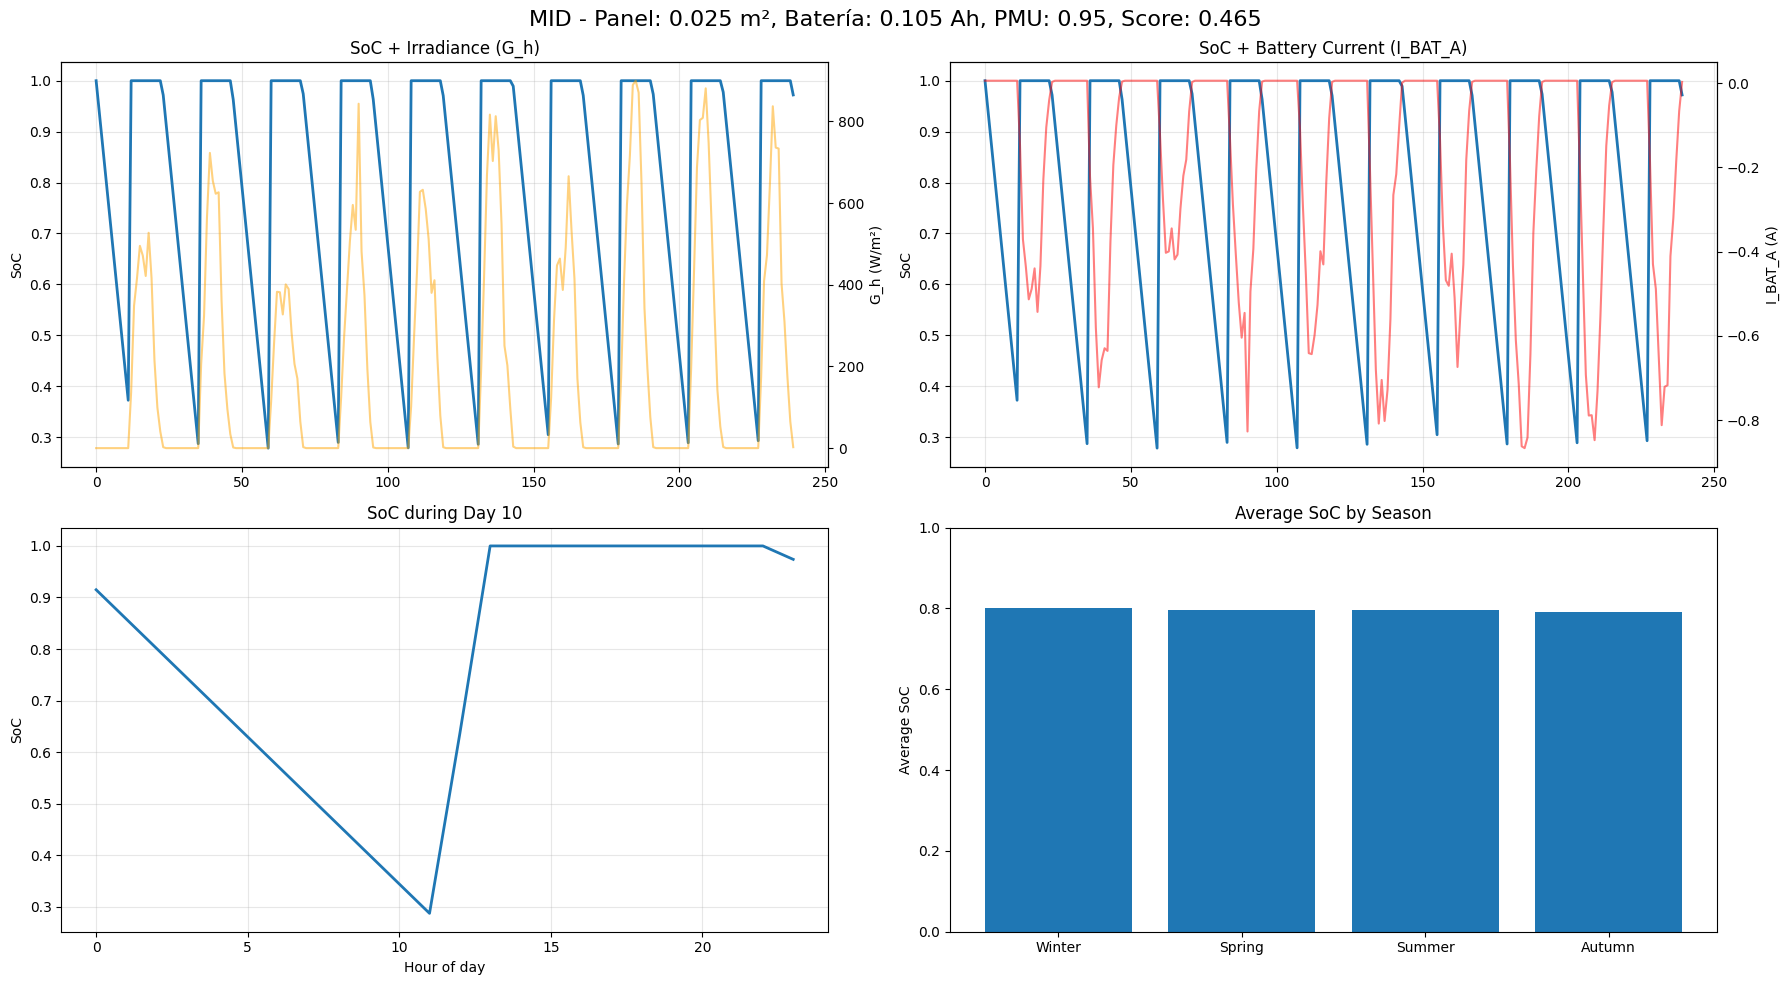

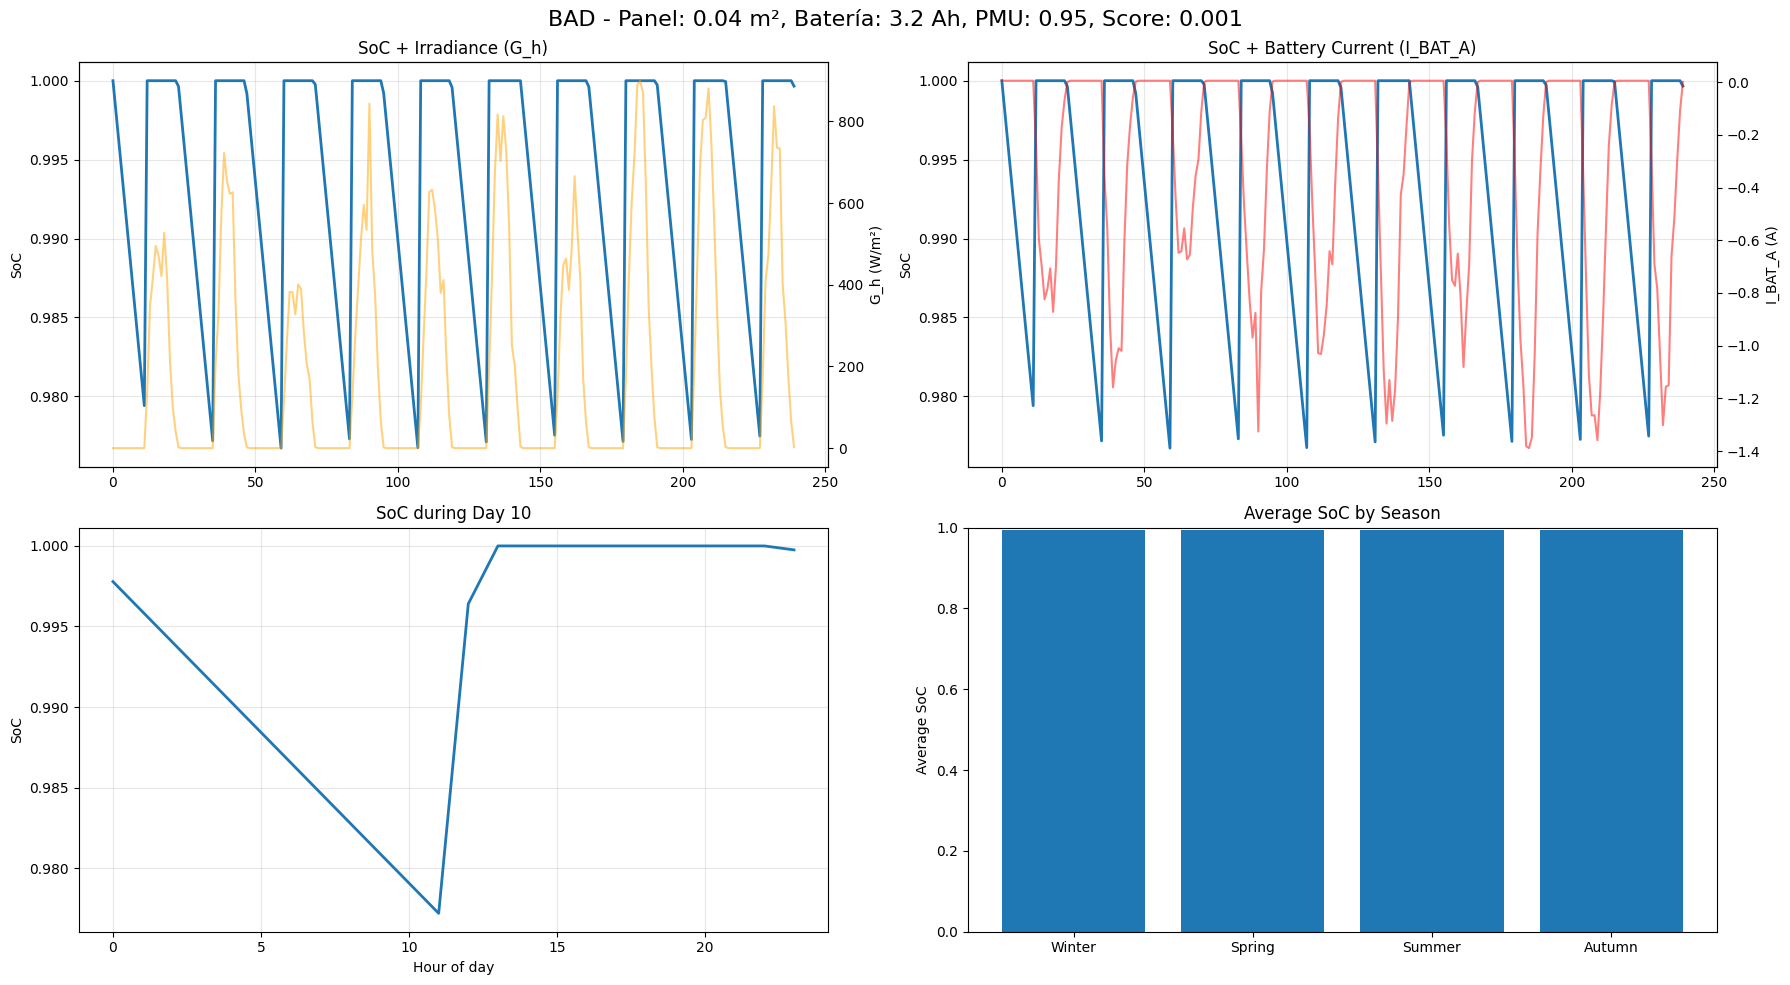

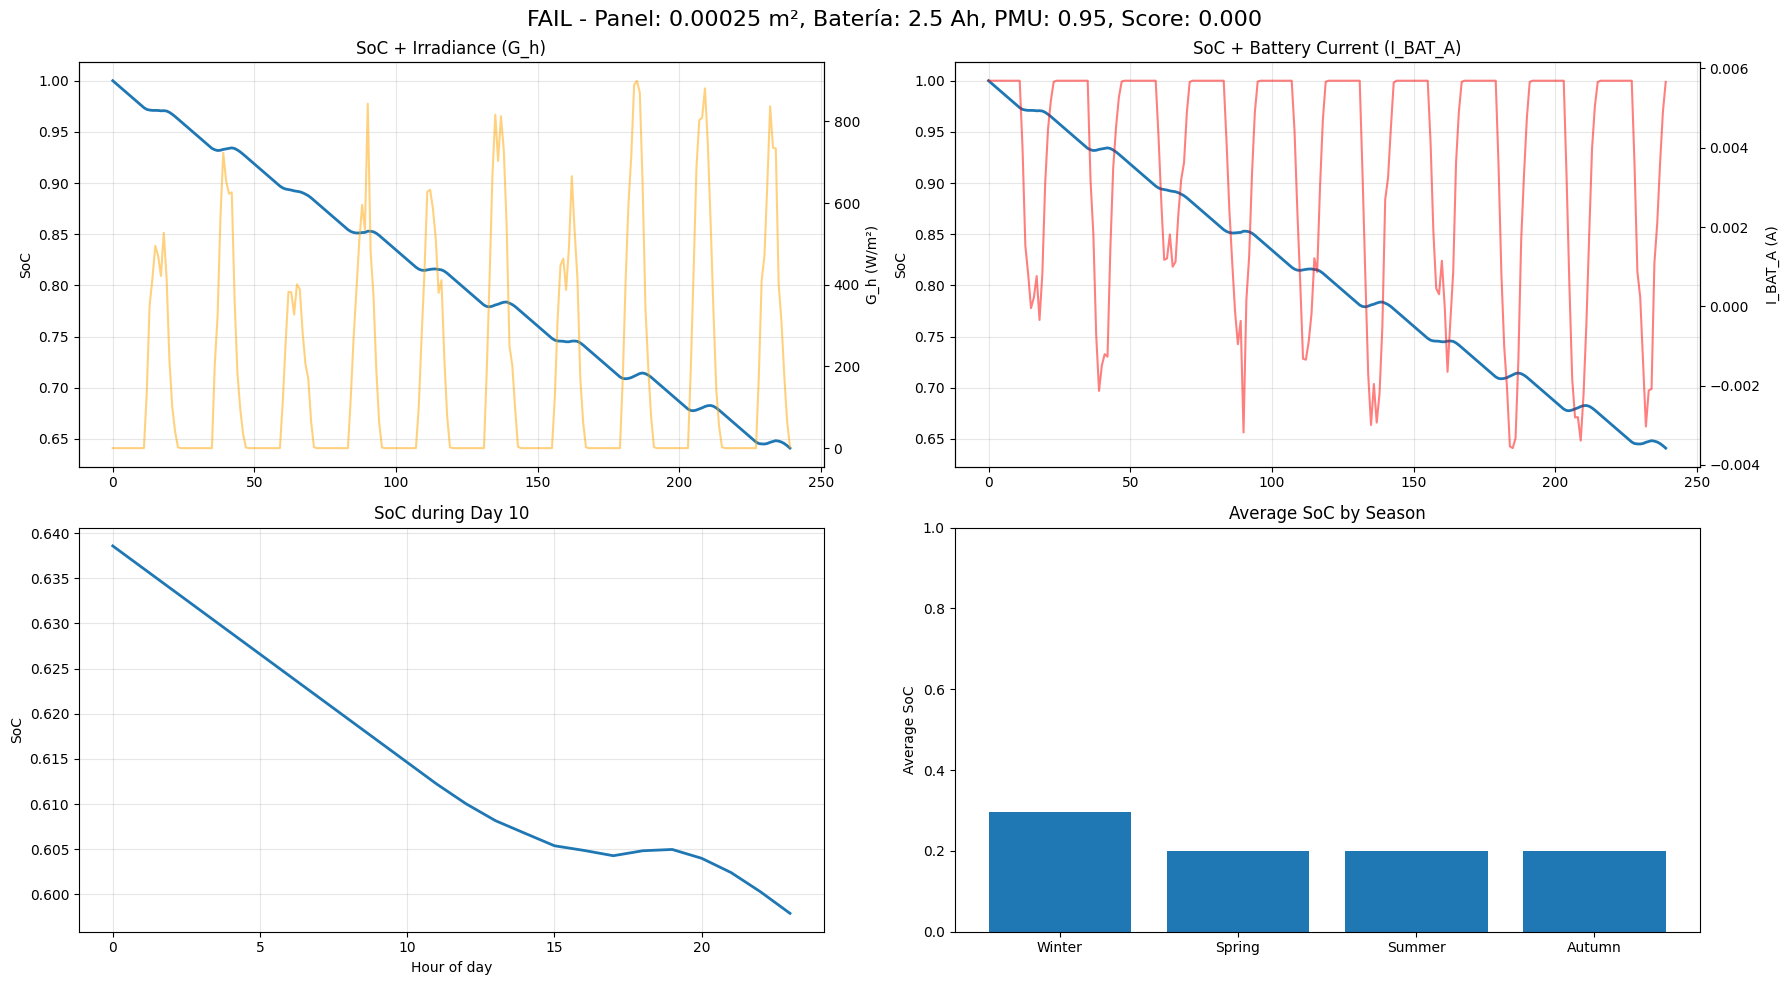

In [36]:
# === BEST SCORE ===
plot_full_soc_analysis(
    title_best,
    df_soc, df_pv,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    hours=240,
    day_index=10
)

# === MID-SCORE (~0.5) ===
plot_full_soc_analysis(
    title_mid,
    df_soc, df_pv,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    hours=240,
    day_index=10
)

# === BAD NON-ZERO SCORE ===
plot_full_soc_analysis(
    title_bad,
    df_soc, df_pv,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    hours=240,
    day_index=10
)

# === FAILURE CASE ===
plot_full_soc_analysis(
    title_fail,
    df_soc, df_pv,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    hours=240,
    day_index=10
)
